In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#load the data set
data = pd.read_csv("E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\breast-cancer.csv",header=None)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       286 non-null    object
 1   1       286 non-null    object
 2   2       286 non-null    object
 3   3       286 non-null    object
 4   4       278 non-null    object
 5   5       286 non-null    object
 6   6       286 non-null    object
 7   7       285 non-null    object
 8   8       286 non-null    object
 9   9       286 non-null    object
dtypes: object(10)
memory usage: 22.5+ KB


In [ ]:
#retrieve array
dataset=data.values
dataset

array([["'40-49'", "'premeno'", "'15-19'", ..., "'left_up'", "'no'",
        "'recurrence-events'"],
       ["'50-59'", "'ge40'", "'15-19'", ..., "'central'", "'no'",
        "'no-recurrence-events'"],
       ["'50-59'", "'ge40'", "'35-39'", ..., "'left_low'", "'no'",
        "'recurrence-events'"],
       ...,
       ["'30-39'", "'premeno'", "'30-34'", ..., "'right_up'", "'no'",
        "'no-recurrence-events'"],
       ["'50-59'", "'premeno'", "'15-19'", ..., "'left_low'", "'no'",
        "'no-recurrence-events'"],
       ["'50-59'", "'ge40'", "'40-44'", ..., "'right_up'", "'no'",
        "'no-recurrence-events'"]], dtype=object)

In [ ]:
#split into input and output variables
X=dataset[:,:-1]
Y=dataset[:,-1]

In [ ]:
#format all fields as strings
X=X.astype(str)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#split the data set into train and test set
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.33, random_state=1)
#print the shape
print("Train", X_train.shape,Y_train.shape)
print("Test",X_test.shape, Y_test.shape)

Train (191, 9) (191,)
Test (95, 9) (95,)


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [ ]:
#prepare the input variables
def prepare_inputs(X_train, X_test):
    oe=OrdinalEncoder()
    oe.fit(X_train)  #first fit the encoding on the training data set
    X_train_enc=oe.transform(X_train)  #then apply it to the train set
    X_test_enc=oe.transform(X_test)   #apply it to the test set
    return X_train_enc, X_test_enc

In [ ]:
#prepare target variable
def prepare_target(Y_train, Y_test):
    le=LabelEncoder()
    le.fit(Y_train)
    Y_train_enc=le.transform(Y_train)
    Y_test_enc=le.transform(Y_test)
    return Y_train_enc, Y_test_enc

In [ ]:
#calling the functions
X_train_enc,X_test_enc=prepare_inputs(X_train,X_test)
Y_train_enc,Y_test_enc=prepare_target(Y_train,Y_test)

In [ ]:
#shape after encoding
print('Train',X_train_enc.shape, Y_train_enc.shape)
print('Test',X_test_enc.shape, Y_test_enc.shape)

Train (191, 9) (191,)
Test (95, 9) (95,)


## Chi-squared Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
def select_features(X_train, Y_train, X_test):
    fs=SelectKBest(score_func=chi2, k='all')
    fs.fit(X_train, Y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs, X_test_fs, fs


In [ ]:
#calling feature selection function
X_train_fs, X_test_fs, fs=select_features(X_train_enc, Y_train_enc, X_test_enc)

In [ ]:
#print the scores
fs.scores_

array([4.72552966e-01, 2.91926930e-02, 2.13765782e+00, 2.93810590e+01,
       8.22260110e+00, 8.10018314e+00, 1.27382179e+00, 9.50681603e-01,
       3.69998905e+00])

In [ ]:
import matplotlib.pyplot as plt

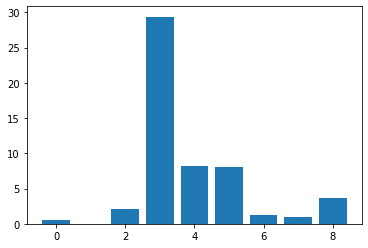

In [ ]:
#plot the scores
plt.bar([i for i in range (len(fs.scores_))],fs.scores_)
plt.show()

From the bar chart, it is inferred that the features 3, 4, 5 and 8 are the most relevant features

## Mutual Information feature selection

---



In [ ]:
from sklearn.feature_selection import mutual_info_classif

In [ ]:
def select_features_2(X_train, Y_train, X_test):
    fs=SelectKBest(score_func=mutual_info_classif, k='all')
    fs.fit(X_train, Y_train)
    X_train_fs_2=fs.transform(X_train)
    X_test_fs_2=fs.transform(X_test)
    return X_train_fs_2, X_test_fs_2, fs


In [ ]:
#calling feature selection function
X_train_fs_2, X_test_fs_2, fs=select_features_2(X_train_enc, Y_train_enc, X_test_enc)

In [ ]:
#print the scores
fs.scores_

array([0.01004129, 0.        , 0.06785375, 0.        , 0.        ,
       0.04636478, 0.        , 0.00134657, 0.03147814])

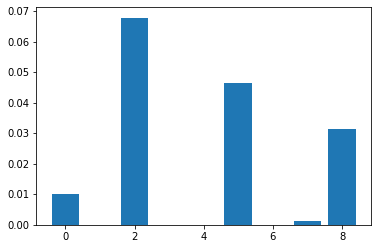

In [ ]:
#plot the scores
plt.bar([i for i in range (len(fs.scores_))],fs.scores_)
plt.show()

It is inferred from the bar chart that the features 0, 2,5 and 8 are relevant features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Model built using ALL features

In [ ]:
#fit the model
model=LogisticRegression(solver='lbfgs')
model.fit(X_train_enc, Y_train_enc)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
#predict the model
yhat=model.predict(X_test_enc)

In [ ]:
#Evaluate the prediction
accuracy=accuracy_score(Y_test_enc, yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 75.79


## Model built using Chi-squared features

In [ ]:
model1=LogisticRegression(solver='lbfgs')
#fit the model
model1.fit(X_train_fs, Y_train_enc)
#evaluate the model
yhat=model1.predict(X_test_fs)
#evaluate the performance
accuracy=accuracy_score(Y_test_enc,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 75.79


## Model built using Mutual Information


In [ ]:
model2=LogisticRegression(solver='lbfgs')
#fit the model
model2.fit(X_train_fs_2, Y_train_enc)
#evaluate the model
yhat=model2.predict(X_test_fs_2)
#evaluate the performance
accuracy=accuracy_score(Y_test_enc,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 75.79


## Conclusion
Models built with all features, chi-square based feature selection or with mutual information based feature selection have the same accuracy percentage.